# LLM Evaluation: Pairwise LLM Judge

In this example, we compare three versions of a shopping assistant.

Unlike reference-based evaluation, pairwise evaluation does not require one ideal answer. Instead, we ask a judge which answer is better for the customer.

To make the judge more human-like, we define a rubric and add a few manually labeled examples as calibration.


In [1]:
# Import libraries
import itertools
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from openai import OpenAI


## 1. Dataset

We start with simple customer questions. There are no reference answers in this setup.


In [2]:
# Static dataset

customer_queries = [
    "How can I track my order?",
    "My item arrived damaged. What should I do?",
    "Can I change my shipping address after placing an order?",
    "What should I do if I ordered the wrong size?",
    "Do stores usually offer free returns?",
    "How long does a refund usually take?",
    "Can I cancel my order after checkout?",
    "What payment methods are usually accepted online?",
]

topics = [
    "tracking",
    "damaged_item",
    "address_change",
    "size_exchange",
    "returns",
    "refunds",
    "cancellation",
    "payments",
]

df = pd.DataFrame(
    {
        "id": range(1, len(customer_queries) + 1),
        "topic": topics,
        "customer_query": customer_queries,
    }
)

df


,id,topic,customer_query
0,1,tracking,How can I track my order?
1,2,damaged_item,My item arrived damaged. What should I do?
2,3,address_change,Can I change my shipping address after placing...
3,4,size_exchange,What should I do if I ordered the wrong size?
4,5,returns,Do stores usually offer free returns?
5,6,refunds,How long does a refund usually take?
6,7,cancellation,Can I cancel my order after checkout?
7,8,payments,What payment methods are usually accepted online?


## 2. Assistant variants

We compare three assistant variants. They can be different models, prompts, temperatures, or all of these.


In [3]:
assistant_variants = [
    {
        "variant_id": "concise_low_temp",
        "model": "gpt-4.1-mini",
        "temperature": 0.1,
        "system_prompt": (
            "You are a concise shopping support assistant. "
            "Answer in 1 to 2 sentences. "
            "Avoid store-specific claims unless the user provided the policy."
        ),
    },
    {
        "variant_id": "warm_high_temp",
        "model": "gpt-4.1-mini",
        "temperature": 0.8,
        "system_prompt": (
            "You are a friendly shopping support assistant. "
            "Be warm and helpful, but do not invent store-specific policies. "
            "Answer in 2 to 4 sentences."
        ),
    },
    {
        "variant_id": "balanced_stronger_model",
        "model": "gpt-4.1",
        "temperature": 0.3,
        "system_prompt": (
            "You are a reliable shopping support assistant. "
            "Give practical next steps, mention uncertainty when policies vary, "
            "and avoid unsupported guarantees."
        ),
    },
]

pd.DataFrame(assistant_variants)[["variant_id", "model", "temperature"]]


,variant_id,model,temperature
0,concise_low_temp,gpt-4.1-mini,0.1
1,warm_high_temp,gpt-4.1-mini,0.8
2,balanced_stronger_model,gpt-4.1,0.3


In [4]:
def generate_answer(client, customer_query, variant):
    response = client.responses.create(
        model=variant["model"],
        temperature=variant["temperature"],
        input=[
            {"role": "system", "content": variant["system_prompt"]},
            {"role": "user", "content": customer_query},
        ],
    )
    return response.output_text.strip()


In [5]:
# Optional real API call
# If OPENAI_API_KEY is available, generate answers live.
# Otherwise, use static demo outputs so the notebook remains runnable.

demo_answers = {
    "concise_low_temp": [
        "You can usually track your order from the shipping confirmation email or your account order history. If tracking is not updating, contact support with your order number.",
        "Take photos of the item and packaging, then contact support. They can review the issue and explain return, refund, or replacement options.",
        "Contact support as soon as possible. Address changes may be possible before shipment, but policies vary by store.",
        "Check whether the store offers exchanges. If not, you may need to return the item and place a new order for the correct size.",
        "Free returns depend on the store and item category. Check the return policy before assuming the return label is free.",
        "Refund timing depends on the store and payment method. It often starts after the returned item is received and inspected.",
        "Contact support quickly. Cancellation may be possible before processing or shipment, but it depends on the store.",
        "Most online stores accept major cards and sometimes digital wallets or gift cards. Check the checkout page for accepted methods.",
    ],
    "warm_high_temp": [
        "No worries — your order should arrive soon! You can track it in your account, and most orders are delivered within 3 to 5 days.",
        "I'm sorry that happened. Please take photos of the damaged item and packaging, then contact support so they can help with the next step.",
        "You can usually change the address from your account even after the order ships. If it does not work, support can reroute it for you.",
        "You can request an exchange for the right size, or return the item and reorder. Check the product page and policy for size-related rules.",
        "Many stores offer free returns, but not always. It depends on the store, product type, and reason for return.",
        "Refunds usually take 5 to 10 business days after the store receives the item, but the exact timing can depend on the payment provider.",
        "You may be able to cancel from your order page shortly after checkout. If the order already shipped, you may need to return it instead.",
        "Online stores commonly accept credit or debit cards, digital wallets, and sometimes gift cards. The available options are shown at checkout.",
    ],
    "balanced_stronger_model": [
        "Use the tracking link in your shipping confirmation email or check the order history in your account. If the link has not updated for a while, contact support with your order number.",
        "Photograph the item and packaging, keep the packaging if possible, and contact support. They can confirm whether a replacement, refund, or return process applies.",
        "Contact support immediately with the correct address. Changes are usually only possible before the order is processed or shipped.",
        "Check the store's exchange policy first. If exchanges are not supported, the usual path is to return the item and place a new order in the correct size.",
        "Free returns vary by store, item type, location, and reason for return. Always check the return policy before assuming the label or shipping is free.",
        "Refund timing varies by store and payment method. Many stores issue the refund after receiving and inspecting the return, then the payment provider may take additional time.",
        "Try cancelling from your order page or contact support right away. Once an order is processed or shipped, cancellation may no longer be available.",
        "Most stores accept major credit or debit cards, and many also support digital wallets, gift cards, or store credit. The checkout page is the source of truth.",
    ],
}

api_key = os.getenv("OPENAI_API_KEY")

if api_key:
    client = OpenAI(api_key=api_key)
    for variant in assistant_variants:
        df[variant["variant_id"]] = df["customer_query"].apply(
            lambda query: generate_answer(client, query, variant)
        )
else:
    for variant_id, answers in demo_answers.items():
        df[variant_id] = answers

df.head()


,id,topic,customer_query,concise_low_temp,warm_high_temp,balanced_stronger_model
0,1,tracking,How can I track my order?,You can track your order by using the tracking...,"To track your order, you can usually find a tr...","To track your order, here are some practical s..."
1,2,damaged_item,My item arrived damaged. What should I do?,Contact the seller or store where you purchase...,I'm sorry to hear your item arrived damaged. I...,I'm sorry your item arrived damaged. Here are ...
2,3,address_change,Can I change my shipping address after placing...,Changing your shipping address after placing a...,Whether you can change your shipping address a...,Whether you can change your shipping address a...
3,4,size_exchange,What should I do if I ordered the wrong size?,"If you ordered the wrong size, check the store...","If you ordered the wrong size, you can usually...","If you ordered the wrong size, here are some p..."
4,5,returns,Do stores usually offer free returns?,"Many stores offer free returns, especially for...","Many stores do offer free returns, especially ...","Many stores do offer free returns, especially ..."


## 3. Build pairwise comparisons

For each query, we compare every pair of variants.


In [6]:
variant_ids = [variant["variant_id"] for variant in assistant_variants]

comparison_rows = []

for _, row in df.iterrows():
    for model_a, model_b in itertools.combinations(variant_ids, 2):
        comparison_rows.append(
            {
                "id": row["id"],
                "topic": row["topic"],
                "customer_query": row["customer_query"],
                "model_a": model_a,
                "model_b": model_b,
                "answer_a": row[model_a],
                "answer_b": row[model_b],
            }
        )

comparisons_df = pd.DataFrame(comparison_rows)

comparisons_df.head()


,id,topic,customer_query,model_a,model_b,answer_a,answer_b
0,1,tracking,How can I track my order?,concise_low_temp,warm_high_temp,You can track your order by using the tracking...,"To track your order, you can usually find a tr..."
1,1,tracking,How can I track my order?,concise_low_temp,balanced_stronger_model,You can track your order by using the tracking...,"To track your order, here are some practical s..."
2,1,tracking,How can I track my order?,warm_high_temp,balanced_stronger_model,"To track your order, you can usually find a tr...","To track your order, here are some practical s..."
3,2,damaged_item,My item arrived damaged. What should I do?,concise_low_temp,warm_high_temp,Contact the seller or store where you purchase...,I'm sorry to hear your item arrived damaged. I...
4,2,damaged_item,My item arrived damaged. What should I do?,concise_low_temp,balanced_stronger_model,Contact the seller or store where you purchase...,I'm sorry your item arrived damaged. Here are ...


## 4. Human-like rubric

The judge uses a rubric, then calibrates on a few manually labeled examples.


In [7]:
criteria = """
Choose the answer that would be better for an e-commerce customer.

Prefer the answer that is:
- sounds professional and respectful
- is clear and helpful
- avoids slang, sarcasm, or aggressive wording
- avoids unnecessary detail.
- polite and easy to understand

If both answers are similarly good, choose tie.
"""

human_labeled_examples = [
    {
        "query": "Can I return an item without a receipt?",
        "answer_a": "Return rules vary by store. Check the return policy or contact support to see whether an order number, account history, or receipt is required.",
        "answer_b": "Yes, you can always return items without a receipt within 90 days.",
        "winner": "A",
        "comment": "A is safer and does not invent a universal 90-day policy.",
    },
    {
        "query": "How long does shipping take?",
        "answer_a": "Shipping depends on your location and selected delivery method.",
        "answer_b": "Shipping depends on your location and delivery method. Most stores show the estimate at checkout or in the confirmation email.",
        "winner": "B",
        "comment": "B is equally correct but more helpful because it tells the customer where to check.",
    },
    {
        "query": "Can I pay with a gift card?",
        "answer_a": "Some stores accept gift cards online, but it depends on the checkout options.",
        "answer_b": "Gift card support depends on the store. Check the payment options at checkout.",
        "winner": "tie",
        "comment": "Both answers are correct, concise, and similarly useful.",
    },
]

pd.DataFrame(human_labeled_examples)


,query,answer_a,answer_b,winner,comment
0,Can I return an item without a receipt?,Return rules vary by store. Check the return p...,"Yes, you can always return items without a rec...",A,A is safer and does not invent a universal 90-...
1,How long does shipping take?,Shipping depends on your location and selected...,Shipping depends on your location and delivery...,B,B is equally correct but more helpful because ...
2,Can I pay with a gift card?,"Some stores accept gift cards online, but it d...",Gift card support depends on the store. Check ...,tie,"Both answers are correct, concise, and similar..."


In [8]:
def format_examples(examples):
    formatted = []

    for i, example in enumerate(examples, start=1):
        formatted.append(
            f"""Example {i}
Customer query: {example["query"]}

Answer A: {example["answer_a"]}

Answer B: {example["answer_b"]}

Winner: {example["winner"]}
Reasoning: {example["comment"]}"""
        )

    return "\n\n".join(formatted)


JUDGE_PROMPT = f"""
You are a human preference judge for a shopping assistant.

{criteria}

Use the calibration examples to align your judgement style.

{format_examples(human_labeled_examples)}

Return valid JSON only with this schema:
{{
  "winner": "A|B|tie",
  "reasoning": "short explanation"
}}
"""


def judge_pairwise(client, row, model="gpt-4.1-mini"):
    response = client.responses.create(
        model=model,
        temperature=0,
        input=[
            {"role": "system", "content": JUDGE_PROMPT},
            {
                "role": "user",
                "content": (
                    f"Customer query: {row['customer_query']}\n\n"
                    f"Answer A: {row['answer_a']}\n\n"
                    f"Answer B: {row['answer_b']}"
                ),
            },
        ],
    )
    return json.loads(response.output_text)


## 5. Run the judge

The judge returns one preference label per pair: `A`, `B`, or `tie`.


In [9]:
# Optional real judge call
# Without an API key, use static demo judgements.

demo_judgements = [
    {
        "winner": "A",
        "reasoning": "A is safer because B adds an unsupported 3 to 5 day delivery claim."
    },
    {
        "winner": "B",
        "reasoning": "B gives the same safe guidance with slightly clearer next steps."
    },
    {
        "winner": "B",
        "reasoning": "B avoids the unsupported delivery timeline and is more reliable."
    },
    {
        "winner": "tie",
        "reasoning": "Both answers give safe and useful next steps for a damaged item."
    },
    {
        "winner": "B",
        "reasoning": "B is more complete because it mentions keeping packaging and explains possible outcomes."
    },
    {
        "winner": "B",
        "reasoning": "B is more complete while staying concise and safe."
    },
    {
        "winner": "A",
        "reasoning": "A is safer because B claims changes are usually possible even after shipment."
    },
    {
        "winner": "B",
        "reasoning": "B is more direct and emphasizes acting before processing or shipment."
    },
    {
        "winner": "B",
        "reasoning": "B avoids the unsupported rerouting claim and gives safer guidance."
    },
    {
        "winner": "B",
        "reasoning": "B is slightly more helpful because it mentions product and policy checks."
    },
    {
        "winner": "B",
        "reasoning": "B is more precise about checking the exchange policy first."
    },
    {
        "winner": "B",
        "reasoning": "B is clearer about the usual path when exchanges are not supported."
    },
    {
        "winner": "tie",
        "reasoning": "Both answers correctly say free returns vary and advise checking the policy."
    },
    {
        "winner": "B",
        "reasoning": "B is more complete because it mentions location and reason for return."
    },
    {
        "winner": "B",
        "reasoning": "B gives more complete conditions without overclaiming."
    },
    {
        "winner": "B",
        "reasoning": "B adds a useful typical timeline while still saying timing can vary."
    },
    {
        "winner": "B",
        "reasoning": "B is more complete because it mentions inspection and payment provider timing."
    },
    {
        "winner": "B",
        "reasoning": "B is safer and more complete about refund timing."
    },
    {
        "winner": "B",
        "reasoning": "B gives a practical path through the order page and explains the return fallback."
    },
    {
        "winner": "B",
        "reasoning": "B is slightly more complete and specific about processed or shipped orders."
    },
    {
        "winner": "tie",
        "reasoning": "Both answers are helpful, safe, and give similar cancellation guidance."
    },
    {
        "winner": "tie",
        "reasoning": "Both answers correctly describe common payment methods and point to checkout."
    },
    {
        "winner": "B",
        "reasoning": "B is more complete because it includes store credit and says checkout is the source of truth."
    },
    {
        "winner": "B",
        "reasoning": "B is slightly more complete while remaining accurate."
    }
]

if api_key:
    client = OpenAI(api_key=api_key)
    comparisons_df["judge_result"] = comparisons_df.apply(
        lambda row: judge_pairwise(client, row),
        axis=1,
    )
else:
    comparisons_df["judge_result"] = demo_judgements

judge_df = pd.json_normalize(comparisons_df["judge_result"])

comparisons_df = pd.concat(
    [comparisons_df.drop(columns=["judge_result"]), judge_df],
    axis=1,
)

comparisons_df.head()


,id,topic,customer_query,model_a,model_b,answer_a,answer_b,winner,reasoning
0,1,tracking,How can I track my order?,concise_low_temp,warm_high_temp,You can track your order by using the tracking...,"To track your order, you can usually find a tr...",B,"Answer B is more detailed and user-friendly, e..."
1,1,tracking,How can I track my order?,concise_low_temp,balanced_stronger_model,You can track your order by using the tracking...,"To track your order, here are some practical s...",A,"Answer A is clear, concise, and professional, ..."
2,1,tracking,How can I track my order?,warm_high_temp,balanced_stronger_model,"To track your order, you can usually find a tr...","To track your order, here are some practical s...",A,"Answer A is clear, concise, and polite, provid..."
3,2,damaged_item,My item arrived damaged. What should I do?,concise_low_temp,warm_high_temp,Contact the seller or store where you purchase...,I'm sorry to hear your item arrived damaged. I...,B,Answer B is more empathetic and offers additio...
4,2,damaged_item,My item arrived damaged. What should I do?,concise_low_temp,balanced_stronger_model,Contact the seller or store where you purchase...,I'm sorry your item arrived damaged. Here are ...,A,"Answer A is clear, concise, and provides the e..."


In [10]:
comparisons_df

,id,topic,customer_query,model_a,model_b,answer_a,answer_b,winner,reasoning
0,1,tracking,How can I track my order?,concise_low_temp,warm_high_temp,You can track your order by using the tracking...,"To track your order, you can usually find a tr...",B,"Answer B is more detailed and user-friendly, e..."
1,1,tracking,How can I track my order?,concise_low_temp,balanced_stronger_model,You can track your order by using the tracking...,"To track your order, here are some practical s...",A,"Answer A is clear, concise, and professional, ..."
2,1,tracking,How can I track my order?,warm_high_temp,balanced_stronger_model,"To track your order, you can usually find a tr...","To track your order, here are some practical s...",A,"Answer A is clear, concise, and polite, provid..."
3,2,damaged_item,My item arrived damaged. What should I do?,concise_low_temp,warm_high_temp,Contact the seller or store where you purchase...,I'm sorry to hear your item arrived damaged. I...,B,Answer B is more empathetic and offers additio...
4,2,damaged_item,My item arrived damaged. What should I do?,concise_low_temp,balanced_stronger_model,Contact the seller or store where you purchase...,I'm sorry your item arrived damaged. Here are ...,A,"Answer A is clear, concise, and provides the e..."
5,2,damaged_item,My item arrived damaged. What should I do?,warm_high_temp,balanced_stronger_model,I'm sorry to hear your item arrived damaged. I...,I'm sorry your item arrived damaged. Here are ...,A,Answer A is more concise while still being pro...
6,3,address_change,Can I change my shipping address after placing...,concise_low_temp,warm_high_temp,Changing your shipping address after placing a...,Whether you can change your shipping address a...,B,Answer B is more detailed and clearly explains...
7,3,address_change,Can I change my shipping address after placing...,concise_low_temp,balanced_stronger_model,Changing your shipping address after placing a...,Whether you can change your shipping address a...,A,"Answer A is more concise and professional, pro..."
8,3,address_change,Can I change my shipping address after placing...,warm_high_temp,balanced_stronger_model,Whether you can change your shipping address a...,Whether you can change your shipping address a...,A,"Answer A is clear, professional, and concise, ..."
9,4,size_exchange,What should I do if I ordered the wrong size?,concise_low_temp,warm_high_temp,"If you ordered the wrong size, check the store...","If you ordered the wrong size, you can usually...",B,"Answer B is more helpful and polite, providing..."


## 6. Convert labels to model wins

A pairwise label says whether answer A or B won. We map that back to the model names.


In [11]:
def winner_model(row):
    if row["winner"] == "A":
        return row["model_a"]
    if row["winner"] == "B":
        return row["model_b"]
    return "tie"


comparisons_df["winner_model"] = comparisons_df.apply(winner_model, axis=1)

comparisons_df[
    [
        "topic",
        "model_a",
        "model_b",
        "winner",
        "winner_model",
        "reasoning",
    ]
].head(10)


,topic,model_a,model_b,winner,winner_model,reasoning
0,tracking,concise_low_temp,warm_high_temp,B,warm_high_temp,"Answer B is more detailed and user-friendly, e..."
1,tracking,concise_low_temp,balanced_stronger_model,A,concise_low_temp,"Answer A is clear, concise, and professional, ..."
2,tracking,warm_high_temp,balanced_stronger_model,A,warm_high_temp,"Answer A is clear, concise, and polite, provid..."
3,damaged_item,concise_low_temp,warm_high_temp,B,warm_high_temp,Answer B is more empathetic and offers additio...
4,damaged_item,concise_low_temp,balanced_stronger_model,A,concise_low_temp,"Answer A is clear, concise, and provides the e..."
5,damaged_item,warm_high_temp,balanced_stronger_model,A,warm_high_temp,Answer A is more concise while still being pro...
6,address_change,concise_low_temp,warm_high_temp,B,warm_high_temp,Answer B is more detailed and clearly explains...
7,address_change,concise_low_temp,balanced_stronger_model,A,concise_low_temp,"Answer A is more concise and professional, pro..."
8,address_change,warm_high_temp,balanced_stronger_model,A,warm_high_temp,"Answer A is clear, professional, and concise, ..."
9,size_exchange,concise_low_temp,warm_high_temp,B,warm_high_temp,"Answer B is more helpful and polite, providing..."


## 7. Summarise results

We can now compute win rates and build a simple leaderboard.


In [12]:
wins = (
    comparisons_df.loc[comparisons_df["winner_model"] != "tie", "winner_model"]
    .value_counts()
    .rename_axis("variant_id")
    .reset_index(name="wins")
)

total_pairs_by_model = []

for variant_id in variant_ids:
    total_pairs_by_model.append(
        {
            "variant_id": variant_id,
            "comparisons": int(
                ((comparisons_df["model_a"] == variant_id) | (comparisons_df["model_b"] == variant_id)).sum()
            ),
        }
    )

leaderboard = pd.DataFrame(total_pairs_by_model).merge(
    wins,
    on="variant_id",
    how="left",
)

leaderboard["wins"] = leaderboard["wins"].fillna(0).astype(int)
leaderboard["win_rate_%"] = (
    leaderboard["wins"] / leaderboard["comparisons"] * 100
).round(1)

leaderboard = leaderboard.sort_values(
    ["win_rate_%", "wins"],
    ascending=False,
)

leaderboard


,variant_id,comparisons,wins,win_rate_%
1,warm_high_temp,16,15,93.8
0,concise_low_temp,16,8,50.0
2,balanced_stronger_model,16,1,6.2


In [13]:
tie_rate = (comparisons_df["winner"] == "tie").mean() * 100

summary = pd.DataFrame(
    {
        "metric": ["total_comparisons", "tie_rate_%"],
        "value": [len(comparisons_df), round(tie_rate, 1)],
    }
)

summary


,metric,value
0,total_comparisons,24.0
1,tie_rate_%,0.0


In [14]:
pairwise_matrix = pd.DataFrame(
    0,
    index=variant_ids,
    columns=variant_ids,
)

for _, row in comparisons_df.iterrows():
    if row["winner_model"] != "tie":
        loser = row["model_b"] if row["winner_model"] == row["model_a"] else row["model_a"]
        pairwise_matrix.loc[row["winner_model"], loser] += 1

pairwise_matrix


,concise_low_temp,warm_high_temp,balanced_stronger_model
concise_low_temp,0,0,8
warm_high_temp,8,0,7
balanced_stronger_model,0,1,0


## 8. Visualise results


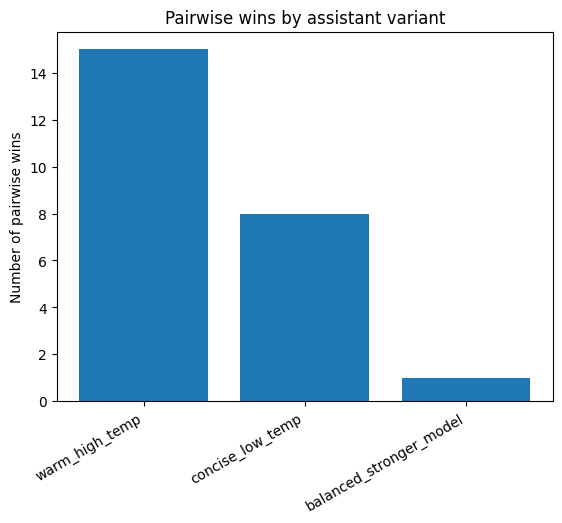

In [15]:
plt.figure()

plt.bar(leaderboard["variant_id"], leaderboard["wins"])
plt.ylabel("Number of pairwise wins")
plt.title("Pairwise wins by assistant variant")
plt.xticks(rotation=30, ha="right")

plt.show()


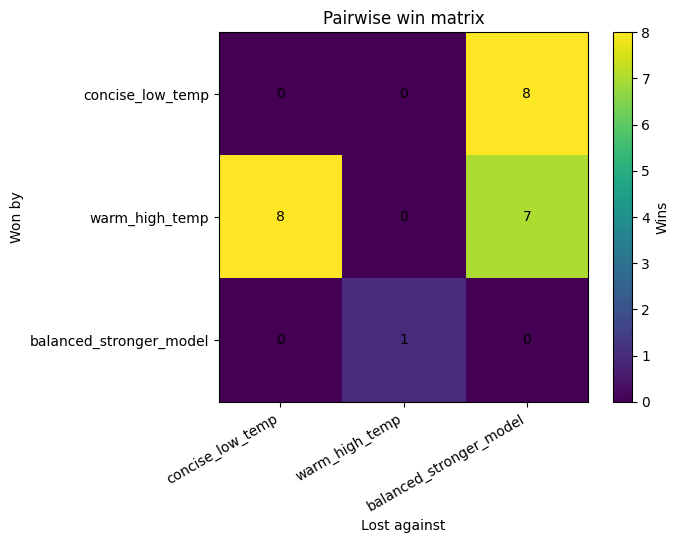

In [17]:
plt.figure()

plt.imshow(pairwise_matrix)
plt.xticks(range(len(pairwise_matrix.columns)), pairwise_matrix.columns, rotation=30, ha="right")
plt.yticks(range(len(pairwise_matrix.index)), pairwise_matrix.index)
plt.colorbar(label="Wins")

plt.title("Pairwise win matrix")
plt.xlabel("Lost against")
plt.ylabel("Won by")

for i in range(pairwise_matrix.shape[0]):
    for j in range(pairwise_matrix.shape[1]):
        plt.text(j, i, pairwise_matrix.values[i, j], ha="center", va="center")

plt.show()


## 9. Final note

Pairwise evaluation is useful when there is no single perfect answer.

The rubric and calibration examples strongly shape the judge. Try changing them and compare how the leaderboard moves.
